# NLP Twitter Methods Comparison

Comparação abrangente de métodos de NLP para classificação de sentimento em tweets.

**Dataset:** [Twitter Entity Sentiment Analysis](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis)

**Métodos avaliados:**
| Modelo | Tipo | Descrição |
|--------|------|-----------|
| TF-IDF + LinearSVC | Clássico | Baseline com bag-of-words + SVM linear |
| Sentence-BERT | Transformer frozen | Embeddings de sentença + classificador |
| DistilBERT | Transformer fine-tuned | Fine-tuning de transformer para classificação |
| BiLSTM | Recorrente | LSTM bidirecional com embeddings treináveis |
| TextCNN | Convolucional | CNN 1D com múltiplos tamanhos de filtro |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

from sentence_transformers import SentenceTransformer

from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast,
    Trainer,
    TrainingArguments,
)

import kagglehub



In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
print(f"PyTorch: {torch.__version__}")

# DL_SUBSAMPLE = 30000  # usando dataset completo
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 2
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)



Dispositivo: cuda
PyTorch: 2.4.1+cu121


In [3]:
print("Carregando dados...")
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
df = pd.read_csv(f"{path}/twitter_training.csv")
df_val = pd.read_csv(f"{path}/twitter_validation.csv")

df.columns = ['id', 'entity', 'sentiment', 'text']
df_val.columns = ['id', 'entity', 'sentiment', 'text']

df = df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)
df_val = df_val.dropna(subset=['text', 'sentiment']).reset_index(drop=True)

print(f"Treino: {df.shape[0]} amostras")
print(f"Validação: {df_val.shape[0]} amostras")



Carregando dados...


Treino: 73995 amostras
Validação: 999 amostras


In [4]:
print("Distribuição treino:")
print(df['sentiment'].value_counts())
print("\nDistribuição validação:")
print(df_val['sentiment'].value_counts())

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df_val['clean_text'] = df_val['text'].apply(clean_text)

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
df_val['label'] = le.transform(df_val['sentiment'])
label_names = le.classes_
print(f"\nClasses: {label_names}")

X_train_full = df['clean_text'].values
y_train_full = df['label'].values
X_val = df_val['clean_text'].values
y_val = df_val['label'].values

X_train_dl = X_train_full
y_train_dl = y_train_full
print(f"\nDL treino completo: {len(X_train_dl)} amostras")



Distribuição treino:
sentiment
Negative      22358
Positive      20654
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

Distribuição validação:
sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    171
Name: count, dtype: int64



Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']

DL treino completo: 73995 amostras


## 1. TF-IDF + LinearSVC

Vetorização TF-IDF (70k features, unigramas + bigramas) seguida de SVM linear.



In [5]:
print("=" * 60)
print("TF-IDF + LinearSVC")
print("=" * 60)

start = time.time()

vectorizer = TfidfVectorizer(max_features=70000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train_full)
X_val_tfidf = vectorizer.transform(X_val)

svc = LinearSVC(C=1.0, max_iter=2000, dual='auto')
svc.fit(X_train_tfidf, y_train_full)
y_pred = svc.predict(X_val_tfidf)

time_svc = time.time() - start
acc_svc = accuracy_score(y_val, y_pred)

print(f"Acurácia: {acc_svc:.4f}")
print(f"Tempo: {time_svc:.2f}s")
print("\nRelatório de Classificação:")
print(classification_report(y_val, y_pred, target_names=label_names))



TF-IDF + LinearSVC


Acurácia: 0.9800
Tempo: 4.35s

Relatório de Classificação:
              precision    recall  f1-score   support

  Irrelevant       0.98      0.98      0.98       171
    Negative       0.99      0.98      0.98       266
     Neutral       0.99      0.98      0.98       285
    Positive       0.97      0.98      0.97       277

    accuracy                           0.98       999
   macro avg       0.98      0.98      0.98       999
weighted avg       0.98      0.98      0.98       999



## 2. Sentence-BERT

Embeddings `all-MiniLM-L6-v2` (congelado) + classificador LinearSVC. Aproveita semântica pré-treinada sem fine-tuning.



In [6]:
print("=" * 60)
print("Sentence-BERT + LinearSVC")
print("=" * 60)

start = time.time()

sbert = SentenceTransformer('all-MiniLM-L6-v2', device=device)

X_train_sbert = sbert.encode(X_train_dl, show_progress_bar=True, batch_size=64)
X_val_sbert = sbert.encode(X_val, show_progress_bar=True, batch_size=64)

clf_sbert = LinearSVC(C=1.0, max_iter=2000, dual='auto')
clf_sbert.fit(X_train_sbert, y_train_dl)
y_pred = clf_sbert.predict(X_val_sbert)

time_sbert = time.time() - start
acc_sbert = accuracy_score(y_val, y_pred)

print(f"Acurácia: {acc_sbert:.4f}")
print(f"Tempo: {time_sbert:.2f}s")
print("\nRelatório de Classificação:")
print(classification_report(y_val, y_pred, target_names=label_names))



Sentence-BERT + LinearSVC


Batches:   0%|          | 0/1157 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Acurácia: 0.6036
Tempo: 33.93s

Relatório de Classificação:
              precision    recall  f1-score   support

  Irrelevant       0.63      0.34      0.44       171
    Negative       0.58      0.76      0.66       266
     Neutral       0.63      0.51      0.56       285
    Positive       0.60      0.71      0.65       277

    accuracy                           0.60       999
   macro avg       0.61      0.58      0.58       999
weighted avg       0.61      0.60      0.59       999



## 3. DistilBERT (Fine-Tuning)

Fine-tuning do `distilbert-base-uncased` para classificação. Requer GPU para treino em tempo hábil.



In [7]:
print("=" * 60)
print("DistilBERT Fine-Tuning")
print("=" * 60)

start = time.time()
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
        )
        return {
            'input_ids': torch.tensor(enc['input_ids']),
            'attention_mask': torch.tensor(enc['attention_mask']),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = TweetDataset(X_train_dl, y_train_dl, tokenizer, MAX_LEN)
val_dataset = TweetDataset(X_val, y_val, tokenizer, MAX_LEN)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=len(label_names),
)

args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    report_to='none',
)

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {'accuracy': accuracy_score(p.label_ids, preds)}

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()
ev = trainer.evaluate()

time_distilbert = time.time() - start
acc_distilbert = ev['eval_accuracy']

print(f"\nAcurácia DistilBERT: {acc_distilbert:.4f}")
print(f"Tempo: {time_distilbert:.2f}s")



DistilBERT Fine-Tuning


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.512500,0.196249,0.940941
2,0.193800,0.100279,0.970971



Acurácia DistilBERT: 0.9710
Tempo: 2421.08s


## 4. BiLSTM (Bidirectional LSTM)

LSTM bidirecional com embeddings treináveis. Captura dependências sequenciais em ambas as direções.



In [8]:
def build_vocab(texts, max_words=20000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for w, _ in counter.most_common(max_words - 2):
        vocab[w] = len(vocab)
    return vocab

def texts_to_seq(texts, vocab, max_len):
    seqs = []
    for t in texts:
        s = [vocab.get(w, vocab['<UNK>']) for w in t.split()]
        if len(s) > max_len:
            s = s[:max_len]
        else:
            s = s + [0] * (max_len - len(s))
        seqs.append(s)
    return np.array(seqs)

vocab = build_vocab(X_train_dl)
vocab_size = len(vocab)
print(f"Vocabulário: {vocab_size} tokens")

X_train_seq = texts_to_seq(X_train_dl, vocab, MAX_LEN)
X_val_seq = texts_to_seq(X_val, vocab, MAX_LEN)

train_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_train_seq, dtype=torch.long),
    torch.tensor(y_train_dl, dtype=torch.long),
)
val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_val_seq, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.long),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)



Vocabulário: 20000 tokens


In [9]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, num_classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        h_n = h_n[-2:, :, :].permute(1, 0, 2).reshape(x.size(0), -1)
        x = self.dropout(h_n)
        return self.fc(x)

print("=" * 60)
print("BiLSTM Training")
print("=" * 60)

start = time.time()
model_bilstm = BiLSTM(vocab_size, num_classes=len(label_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_bilstm.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    model_bilstm.train()
    loss_acc = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_bilstm(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_acc += loss.item()

    model_bilstm.eval()
    preds, true = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_bilstm(inputs)
            preds.extend(outputs.argmax(1).cpu().numpy())
            true.extend(labels.cpu().numpy())
    acc = accuracy_score(true, preds)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss_acc/len(train_loader):.4f} - Acc: {acc:.4f}")

time_bilstm = time.time() - start
acc_bilstm = accuracy_score(true, preds)
print(f"\nAcurácia BiLSTM: {acc_bilstm:.4f}")
print(f"Tempo: {time_bilstm:.2f}s")



BiLSTM Training


Epoch 1/2 - Loss: 1.0606 - Acc: 0.7718


Epoch 2/2 - Loss: 0.7008 - Acc: 0.8809

Acurácia BiLSTM: 0.8809
Tempo: 13.26s


## 5. TextCNN

CNN 1D com filtros de tamanhos 3, 4 e 5 (100 filtros cada). Captura padrões locais de n-gramas.



In [10]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, filter_sizes=(3, 4, 5),
                 num_filters=100, num_classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs, padding=fs - 2)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        pooled = []
        for conv in self.convs:
            out = torch.relu(conv(x))
            pooled.append(torch.max_pool1d(out, out.size(2)).squeeze(2))
        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)
        return self.fc(x)

print("=" * 60)
print("TextCNN Training")
print("=" * 60)

start = time.time()
model_textcnn = TextCNN(vocab_size, num_classes=len(label_names)).to(device)
optimizer = optim.Adam(model_textcnn.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    model_textcnn.train()
    loss_acc = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_textcnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_acc += loss.item()

    model_textcnn.eval()
    preds, true = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_textcnn(inputs)
            preds.extend(outputs.argmax(1).cpu().numpy())
            true.extend(labels.cpu().numpy())
    acc = accuracy_score(true, preds)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss_acc/len(train_loader):.4f} - Acc: {acc:.4f}")

time_textcnn = time.time() - start
acc_textcnn = accuracy_score(true, preds)
print(f"\nAcurácia TextCNN: {acc_textcnn:.4f}")
print(f"Tempo: {time_textcnn:.2f}s")



TextCNN Training


Epoch 1/2 - Loss: 1.0789 - Acc: 0.7988


Epoch 2/2 - Loss: 0.7185 - Acc: 0.9530

Acurácia TextCNN: 0.9530
Tempo: 13.00s


## 6. Comparação de Resultados



            Modelo  Acurácia  Tempo (s)
TF-IDF + LinearSVC  0.979980       4.35
        DistilBERT  0.970971    2421.08
           TextCNN  0.952953      13.00
            BiLSTM  0.880881      13.26
     Sentence-BERT  0.603604      33.93


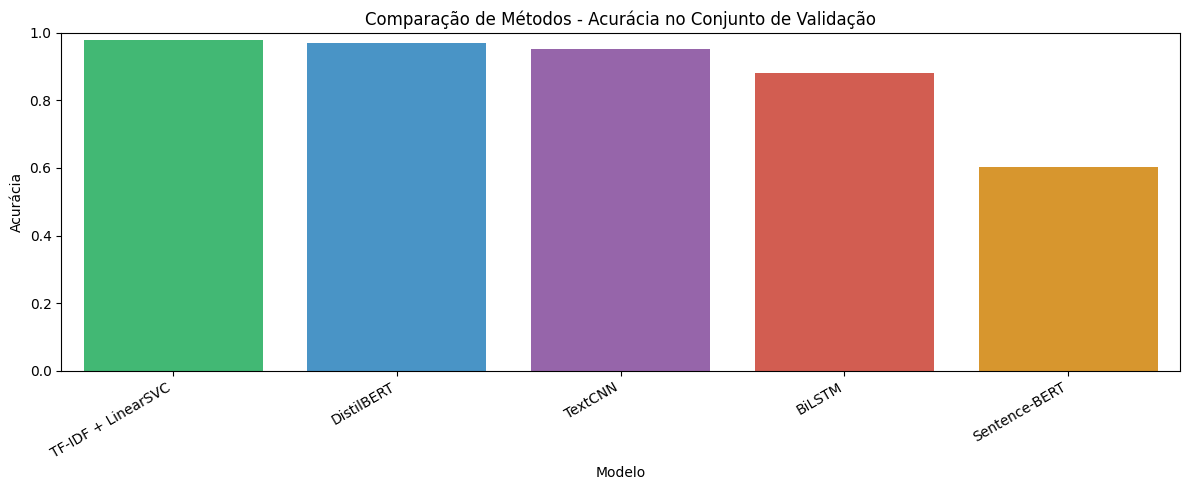

Nota: Resultados podem variar conforme seed, subamostragem e hardware.


In [11]:
results = pd.DataFrame({
    'Modelo': [
        'TF-IDF + LinearSVC', 'Sentence-BERT', 'DistilBERT',
        'BiLSTM', 'TextCNN',
    ],
    'Acurácia': [acc_svc, acc_sbert, acc_distilbert, acc_bilstm, acc_textcnn],
})
results['Tempo (s)'] = [
    round(time_svc, 2), round(time_sbert, 2), round(time_distilbert, 2),
    round(time_bilstm, 2), round(time_textcnn, 2),
]
results = results.sort_values('Acurácia', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

plt.figure(figsize=(12, 5))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']
sns.barplot(data=results, x='Modelo', y='Acurácia', palette=colors)
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.title('Comparação de Métodos - Acurácia no Conjunto de Validação')
plt.tight_layout()
plt.show()

print("Nota: Resultados podem variar conforme seed, subamostragem e hardware.")

